# Baseline models: predicting post success

A ladder of baselines, from the simplest possible model up to an MLP with one hidden layer.
Each model must beat the models above it to justify its added complexity.

| # | Model | Uses |
|---|---|---|
| 0 | Constant (training base rate) | nothing |
| 1 | Subreddit base rate | subreddit |
| 2 | Subreddit × post type base rate | subreddit, post type |
| 3 | Naive Bayes | text (title + body) |
| 4 | Logistic regression | metadata |
| 5 | Logistic regression | text |
| 6 | Logistic regression | metadata + text |
| 7 | MLP, one hidden layer | metadata + text |

## Design decisions (all are settings in the config cell)

- **Data:** 2025 submissions, sampled as in `eda.ipynb`, with NSFW and deleted/removed posts excluded (`reddit_data.py`).
- **Label:** a post is a success if its **engagement is above its subreddit's 90th percentile**, where
  `engagement = log(1 + score) + log(1 + num_comments)`. Score and comments measure different kinds of success
  (upvoted vs. discussed): only about half of the top 10% by score are also in the top 10% by comments.
  The logs stop raw score, which is much larger, from dominating the sum. `LABEL_METRIC` switches the label to
  score only or comments only. The threshold comes from the training months only. A label relative to the subreddit stops the model from only learning
  "big subreddits get big scores". Subreddits with fewer than `MIN_SUB_POSTS` training posts have no reliable
  threshold, so their posts are dropped.
- **Split by time:** train on January to September, validate on October, test on November and December.
  This matches the real task (predict new posts) and prevents leaks from the future.
- **Features:** only information that is known when the post is created. `score` and `num_comments` are
  never features, because they are the outcome.
- **Metrics:** about 9% of posts are positive, so accuracy is not useful. The main metric is **PR-AUC**
  (average precision; a random model scores the base rate). ROC-AUC and log loss are also reported.
  Choose models on the validation set. Look at the test set only for the final comparison.

In [1]:
import copy
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, precision_recall_curve, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import reddit_data

pd.set_option("display.float_format", "{:,.4f}".format)

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
})

/private/tmp/claude-501/-Users-znorton-git-reddit-post-predictor/b748d9c0-e375-4234-9d23-e809649a4ec6/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration and data

In [2]:
YEAR = 2025
SHARDS_PER_MONTH = 12
DATA_DIR = "data/arctic"

TRAIN_MONTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9]
VAL_MONTHS = [10]
TEST_MONTHS = [11, 12]

LABEL_METRIC = "engagement"  # "engagement", "score", or "comments"
SUCCESS_QUANTILE = 0.9       # success = metric above this quantile of the subreddit's training posts
MIN_SUB_POSTS = 50       # subreddits need this many training posts for a reliable threshold
N_TRAIN, N_VAL, N_TEST = 1_000_000, 200_000, 200_000
SEED = 42

In [3]:
# Every metric is on a log scale, so its subreddit statistics are directly usable as features
METRICS = {
    "score": "ln(1 + greatest(score, 0))",
    "comments": "ln(1 + num_comments)",
    "engagement": "ln(1 + greatest(score, 0)) + ln(1 + num_comments)",
}
METRIC_SQL = METRICS[LABEL_METRIC]

shards = reddit_data.select_shards(YEAR, shards_per_month=SHARDS_PER_MONTH)
con = reddit_data.connect(reddit_data.download(shards, DATA_DIR))
q = lambda sql: con.execute(sql).df()
months_sql = lambda ms: ", ".join(str(m) for m in ms)
print(f"{len(shards)} shards; {con.execute('SELECT count(*) FROM subs').fetchone()[0]:,} posts after filters")

Fetching 144 files:   0%|          | 0/144 [00:00<?, ?it/s]

Fetching 144 files: 100%|██████████| 144/144 [00:00<00:00, 2212.30it/s]

144 shards; 35,589,604 posts after filters


## 2. Labels and subreddit statistics

`metric` is the label metric chosen in the config (log scale). A post is a success if its `metric` is above
its subreddit's threshold.

All subreddit statistics come from the **training months only**, from all sampled posts (not only the
model's training sample). These statistics are also features for the models.

`sub_type_rate` is the success rate of each subreddit × post type pair. It is smoothed toward the
subreddit rate, so pairs with few posts do not get extreme values.

In [4]:
TRAIN_SQL = f"month(created_at) IN ({months_sql(TRAIN_MONTHS)})"

con.execute(f"CREATE OR REPLACE VIEW subs_m AS SELECT *, {METRIC_SQL} AS metric FROM subs")

con.execute(f"""
CREATE OR REPLACE TABLE sub_stats AS
SELECT subreddit, count(*) AS sub_posts,
       quantile_cont(metric, {SUCCESS_QUANTILE}) AS threshold,
       median(metric) AS sub_median
FROM subs_m WHERE {TRAIN_SQL}
GROUP BY subreddit HAVING count(*) >= {MIN_SUB_POSTS}
""")

con.execute(f"""
CREATE OR REPLACE VIEW labeled AS
SELECT s.*, {reddit_data.POST_TYPE_SQL} AS post_type, month(s.created_at) AS month,
       s.metric > st.threshold AS label
FROM subs_m s JOIN sub_stats st USING (subreddit)
""")

SMOOTHING = 20  # pseudo-posts at the subreddit rate added to each subreddit x post type pair
con.execute(f"""
CREATE OR REPLACE TABLE sub_rates AS
WITH sub AS (
  SELECT subreddit, avg(label::INT) AS sub_rate FROM labeled WHERE {TRAIN_SQL} GROUP BY 1
), sub_type AS (
  SELECT subreddit, post_type, sum(label::INT) AS pos, count(*) AS n FROM labeled WHERE {TRAIN_SQL} GROUP BY 1, 2
)
SELECT st.subreddit, st.post_type, sub.sub_rate,
       (st.pos + {SMOOTHING} * sub.sub_rate) / (st.n + {SMOOTHING}) AS sub_type_rate
FROM sub_type st JOIN sub USING (subreddit)
""")

q(f"""
SELECT count(*) AS subreddits_with_threshold, sum(sub_posts) AS training_posts,
       median(threshold) AS median_threshold
FROM sub_stats
""").T.rename(columns={0: "value"})

,value
subreddits_with_threshold,"45,903.0000"
training_posts,"24,490,558.0000"
median_threshold,5.6539


In [5]:
# Share of posts that keep a label (their subreddit has a threshold), and the base rate, by split
q(f"""
SELECT CASE WHEN month(s.created_at) IN ({months_sql(TRAIN_MONTHS)}) THEN '1 train'
            WHEN month(s.created_at) IN ({months_sql(VAL_MONTHS)}) THEN '2 val' ELSE '3 test' END AS split,
       count(*) AS posts,
       avg((st.subreddit IS NOT NULL)::INT) AS frac_labeled,
       avg((s.metric > st.threshold)::INT) FILTER (st.subreddit IS NOT NULL) AS success_rate
FROM subs_m s LEFT JOIN sub_stats st USING (subreddit)
GROUP BY 1 ORDER BY 1
""")

,split,posts,frac_labeled,success_rate
0,1 train,27019609,0.9064,0.0920
1,2 val,3056473,0.8768,0.0869
2,3 test,5513522,0.8317,0.0962


### How the three label choices compare (training months)

Each label is "top 10% in the subreddit" for a different metric. The table shows, for the posts that are
successful under the row's label, the share that are also successful under each column's label.

In [6]:
names = list(METRICS)
q(f"""
CREATE OR REPLACE TEMP TABLE label_cmp AS
WITH t AS (
  SELECT subreddit, {", ".join(f"quantile_cont({METRICS[n]}, {SUCCESS_QUANTILE}) AS t_{n}" for n in names)}
  FROM subs WHERE {TRAIN_SQL} GROUP BY 1 HAVING count(*) >= {MIN_SUB_POSTS}
)
SELECT {", ".join(f"{METRICS[n]} > t_{n} AS {n}" for n in names)}
FROM subs JOIN t USING (subreddit) WHERE {TRAIN_SQL}
""")
overlap = pd.DataFrame(
    {col: [con.execute(f"SELECT avg({col}::INT) FROM label_cmp WHERE {row}").fetchone()[0] for row in names]
     for col in names}, index=names)
overlap.index.name = "successful by"
overlap.columns.name = "also successful by"
overlap

also successful by,score,comments,engagement
successful by,,,
score,1.0000,0.5031,0.7966
comments,0.5056,1.0000,0.7255
engagement,0.7537,0.6830,1.0000


## 3. Sample and features

Each split is a fixed random sample. Only training posts fit the models; validation and test posts are
held out. The "body" text is the first 1,000 characters of `selftext`.

In [7]:
def split_sample(name, months, n):
    return f"""
    SELECT '{name}' AS split, * FROM (
      SELECT * FROM labeled WHERE month IN ({months_sql(months)})
    ) USING SAMPLE reservoir({n} ROWS) REPEATABLE ({SEED})
    """

t0 = time.time()
df = q(f"""
WITH sample AS (
  {split_sample('train', TRAIN_MONTHS, N_TRAIN)}
  UNION ALL {split_sample('val', VAL_MONTHS, N_VAL)}
  UNION ALL {split_sample('test', TEST_MONTHS, N_TEST)}
)
SELECT s.split, s.label::INT AS label, s.subreddit, s.post_type,
       hour(s.created_at) AS hour, isodow(s.created_at) AS dow,
       s.title, left(coalesce(s.selftext, ''), 1000) AS body,
       ln(s.title_length + 1)                                  AS log_title_length,
       len(string_split(s.title, ' '))                         AS title_words,
       ln(length(coalesce(s.selftext, '')) + 1)                AS log_body_length,
       contains(s.title, '?')::INT                             AS title_has_question,
       regexp_matches(s.title, '\\d')::INT                   AS title_has_number,
       (s.title = upper(s.title) AND regexp_matches(s.title, '[A-Z]'))::INT AS title_all_caps,
       (s.link_flair_text IS NOT NULL)::INT                    AS has_link_flair,
       (s.author_flair_text IS NOT NULL)::INT                  AS has_author_flair,
       ln(st.sub_posts)                                        AS sub_log_posts,
       st.threshold                                            AS sub_threshold,
       st.sub_median                                           AS sub_median,
       r.sub_rate,
       coalesce(rt.sub_type_rate, r.sub_rate)                  AS sub_type_rate
FROM sample s
JOIN sub_stats st USING (subreddit)
JOIN (SELECT DISTINCT subreddit, sub_rate FROM sub_rates) r USING (subreddit)
LEFT JOIN sub_rates rt ON rt.subreddit = s.subreddit AND rt.post_type = s.post_type
""")
print(f"Loaded {len(df):,} rows in {time.time() - t0:.0f}s")

train, val, test = (df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"])
y_train, y_val, y_test = train.label.to_numpy(), val.label.to_numpy(), test.label.to_numpy()
del df
pd.DataFrame({"posts": [len(train), len(val), len(test)],
              "success_rate": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["train", "val", "test"])

Loaded 1,400,000 rows in 55s


,posts,success_rate
train,1000000,0.0922
val,200000,0.0870
test,200000,0.0964


### Feature sets

- **Metadata:** post type, hour and weekday (one-hot), title and body measurements, flair flags,
  and the subreddit statistics from section 2. Numeric features are standardized. Each one-hot group drops
  its first category (gallery posts, hour 0, Monday), so those coefficients are relative to that category.
- **Text:** TF-IDF of words and word pairs in the title and body, fit on training posts only.

In [8]:
NUMERIC = ["log_title_length", "title_words", "log_body_length", "sub_log_posts", "sub_threshold",
           "sub_median", "sub_rate", "sub_type_rate"]
BINARY = ["title_has_question", "title_has_number", "title_all_caps", "has_link_flair", "has_author_flair"]
CATEGORICAL = ["post_type", "hour", "dow"]

meta = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
], sparse_threshold=1.0)
X_meta_train = sparse.csr_matrix(meta.fit_transform(train), dtype=np.float32)
X_meta_val = sparse.csr_matrix(meta.transform(val), dtype=np.float32)
X_meta_test = sparse.csr_matrix(meta.transform(test), dtype=np.float32)

text_of = lambda d: (d.title + " \n " + d.body).to_numpy()
t0 = time.time()
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=50_000, sublinear_tf=True,
                        strip_accents="unicode", dtype=np.float32)
X_text_train = tfidf.fit_transform(text_of(train))
X_text_val, X_text_test = tfidf.transform(text_of(val)), tfidf.transform(text_of(test))
print(f"TF-IDF: {X_text_train.shape[1]:,} terms in {time.time() - t0:.0f}s")

X_all_train = sparse.hstack([X_meta_train, X_text_train]).tocsr()
X_all_val = sparse.hstack([X_meta_val, X_text_val]).tocsr()
X_all_test = sparse.hstack([X_meta_test, X_text_test]).tocsr()
print("metadata features:", X_meta_train.shape[1], "| all features:", X_all_train.shape[1])

TF-IDF: 50,000 terms in 89s
metadata features: 46 | all features: 50046


## 4. Models

In [9]:
results = {}
preds = {}

def evaluate(name, p_val, p_test, seconds=None):
    p_val, p_test = np.clip(p_val, 1e-6, 1 - 1e-6), np.clip(p_test, 1e-6, 1 - 1e-6)
    row = {}
    for split, y, p in [("val", y_val, p_val), ("test", y_test, p_test)]:
        row[f"{split}_pr_auc"] = average_precision_score(y, p)
        row[f"{split}_roc_auc"] = roc_auc_score(y, p)
        row[f"{split}_log_loss"] = log_loss(y, p)
    row["fit_seconds"] = seconds
    results[name] = row
    preds[name] = (p_val, p_test)
    return pd.DataFrame(results).T

def fit_timed(model, X, y):
    t0 = time.time()
    model.fit(X, y)
    return model, time.time() - t0

### 0. Constant

Predict the training success rate for every post. PR-AUC equals the base rate, and ROC-AUC is 0.5.
Every other model must beat this.

In [10]:
base_rate = y_train.mean()
evaluate("0 constant", np.full(len(val), base_rate), np.full(len(test), base_rate))

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN


### 1. Subreddit base rate

Predict the subreddit's training success rate. Because of ties at low scores, the rate is not exactly
10% in every subreddit, so this lookup already ranks posts.

In [11]:
evaluate("1 subreddit rate", val.sub_rate, test.sub_rate)

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN


### 2. Subreddit × post type base rate

In [12]:
evaluate("2 subreddit x type rate", val.sub_type_rate, test.sub_type_rate)

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN
2 subreddit x type rate,0.1632,0.6721,0.2797,0.1688,0.6667,0.3005,NaN


### 3. Naive Bayes (text)

In [13]:
nb_model, secs = fit_timed(MultinomialNB(alpha=0.1), X_text_train, y_train)
evaluate("3 naive bayes (text)", nb_model.predict_proba(X_text_val)[:, 1],
         nb_model.predict_proba(X_text_test)[:, 1], secs)

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN
2 subreddit x type rate,0.1632,0.6721,0.2797,0.1688,0.6667,0.3005,NaN
3 naive bayes (text),0.1340,0.6482,0.2873,0.1388,0.6259,0.3118,0.1277


### 4–6. Logistic regression

In [14]:
def logreg():
    return LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs")

lr_meta, secs = fit_timed(logreg(), X_meta_train, y_train)
evaluate("4 logreg (metadata)", lr_meta.predict_proba(X_meta_val)[:, 1], lr_meta.predict_proba(X_meta_test)[:, 1], secs)

lr_text, secs = fit_timed(logreg(), X_text_train, y_train)
evaluate("5 logreg (text)", lr_text.predict_proba(X_text_val)[:, 1], lr_text.predict_proba(X_text_test)[:, 1], secs)

lr_all, secs = fit_timed(logreg(), X_all_train, y_train)
evaluate("6 logreg (metadata + text)", lr_all.predict_proba(X_all_val)[:, 1], lr_all.predict_proba(X_all_test)[:, 1], secs)

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN
2 subreddit x type rate,0.1632,0.6721,0.2797,0.1688,0.6667,0.3005,NaN
3 naive bayes (text),0.1340,0.6482,0.2873,0.1388,0.6259,0.3118,0.1277
4 logreg (metadata),0.1663,0.6751,0.2800,0.1743,0.6744,0.3006,1.0334
5 logreg (text),0.1422,0.6400,0.2862,0.1485,0.6355,0.3080,6.7031
6 logreg (metadata + text),0.1860,0.7000,0.2759,0.1988,0.7031,0.2952,38.7167


In [15]:
# Metadata coefficients of model 4 (features are standardized, so sizes are comparable)
meta_names = [n.split("__", 1)[1] for n in meta.get_feature_names_out()]
coef = pd.Series(lr_meta.coef_[0], index=meta_names).sort_values()
pd.concat([coef.head(10), coef.tail(10)]).to_frame("coefficient")

,coefficient
hour_6,-0.1798
hour_5,-0.1582
hour_4,-0.1509
hour_8,-0.1354
hour_7,-0.1340
hour_2,-0.1073
hour_20,-0.1021
hour_3,-0.0988
hour_22,-0.0987
sub_threshold,-0.0890


In [16]:
# Terms with the largest coefficients in model 5
terms = tfidf.get_feature_names_out()
order = np.argsort(lr_text.coef_[0])
pd.DataFrame({"most negative": terms[order[:25]], "most positive": terms[order[::-1][:25]]})

,most negative,most positive
0,headline,last night
1,post title,go first
2,m4f,thanks to
3,has anyone,giveaway
4,gesucht,ocs
5,top stories,rejected
6,wtb,19f
7,question about,announced
8,sports,good luck
9,question,illegal


### 7. MLP with one hidden layer (metadata + text)

`MLPClassifier.partial_fit` runs one epoch per call. The loop keeps the epoch with the best validation
PR-AUC (early stopping on the metric that matters, not on accuracy).

In [17]:
HIDDEN_UNITS = 64
MAX_EPOCHS = 8
PATIENCE = 2

mlp = MLPClassifier(hidden_layer_sizes=(HIDDEN_UNITS,), activation="relu", alpha=1e-4,
                    batch_size=1024, learning_rate_init=1e-3, random_state=SEED)
best_ap, best_mlp, history, bad_epochs = -1, None, [], 0
rng = np.random.default_rng(SEED)
t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    perm = rng.permutation(X_all_train.shape[0])
    mlp.partial_fit(X_all_train[perm], y_train[perm], classes=[0, 1])
    ap = average_precision_score(y_val, mlp.predict_proba(X_all_val)[:, 1])
    history.append({"epoch": epoch, "train_loss": mlp.loss_, "val_pr_auc": ap})
    print(f"epoch {epoch}: train loss {mlp.loss_:.4f}, val PR-AUC {ap:.4f} ({time.time() - t0:.0f}s)")
    if ap > best_ap:
        best_ap, best_mlp, bad_epochs = ap, copy.deepcopy(mlp), 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            break
secs = time.time() - t0

evaluate("7 mlp, 1 hidden layer (metadata + text)", best_mlp.predict_proba(X_all_val)[:, 1],
         best_mlp.predict_proba(X_all_test)[:, 1], secs)

epoch 1: train loss 0.2854, val PR-AUC 0.1926 (9s)


epoch 2: train loss 0.2649, val PR-AUC 0.1922 (19s)


epoch 3: train loss 0.2508, val PR-AUC 0.1863 (28s)


,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN
2 subreddit x type rate,0.1632,0.6721,0.2797,0.1688,0.6667,0.3005,NaN
3 naive bayes (text),0.1340,0.6482,0.2873,0.1388,0.6259,0.3118,0.1277
4 logreg (metadata),0.1663,0.6751,0.2800,0.1743,0.6744,0.3006,1.0334
5 logreg (text),0.1422,0.6400,0.2862,0.1485,0.6355,0.3080,6.7031
6 logreg (metadata + text),0.1860,0.7000,0.2759,0.1988,0.7031,0.2952,38.7167
"7 mlp, 1 hidden layer (metadata + text)",0.1926,0.7212,0.2709,0.2012,0.7106,0.2917,28.0932


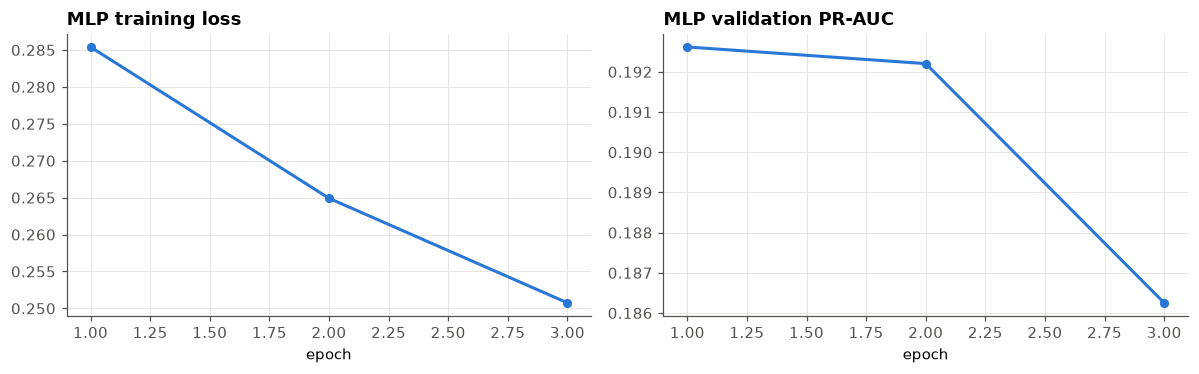

In [18]:
h = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(h.epoch, h.train_loss, color=BLUE, linewidth=2, marker="o", markersize=5)
axes[0].set_title("MLP training loss"); axes[0].set_xlabel("epoch")
axes[1].plot(h.epoch, h.val_pr_auc, color=BLUE, linewidth=2, marker="o", markersize=5)
axes[1].set_title("MLP validation PR-AUC"); axes[1].set_xlabel("epoch")
plt.tight_layout()

## 5. Comparison

In [19]:
res = pd.DataFrame(results).T
res

,val_pr_auc,val_roc_auc,val_log_loss,test_pr_auc,test_roc_auc,test_log_loss,fit_seconds
0 constant,0.0870,0.5000,0.2957,0.0964,0.5000,0.3171,NaN
1 subreddit rate,0.1037,0.5664,0.2917,0.1083,0.5382,0.3138,NaN
2 subreddit x type rate,0.1632,0.6721,0.2797,0.1688,0.6667,0.3005,NaN
3 naive bayes (text),0.1340,0.6482,0.2873,0.1388,0.6259,0.3118,0.1277
4 logreg (metadata),0.1663,0.6751,0.2800,0.1743,0.6744,0.3006,1.0334
5 logreg (text),0.1422,0.6400,0.2862,0.1485,0.6355,0.3080,6.7031
6 logreg (metadata + text),0.1860,0.7000,0.2759,0.1988,0.7031,0.2952,38.7167
"7 mlp, 1 hidden layer (metadata + text)",0.1926,0.7212,0.2709,0.2012,0.7106,0.2917,28.0932


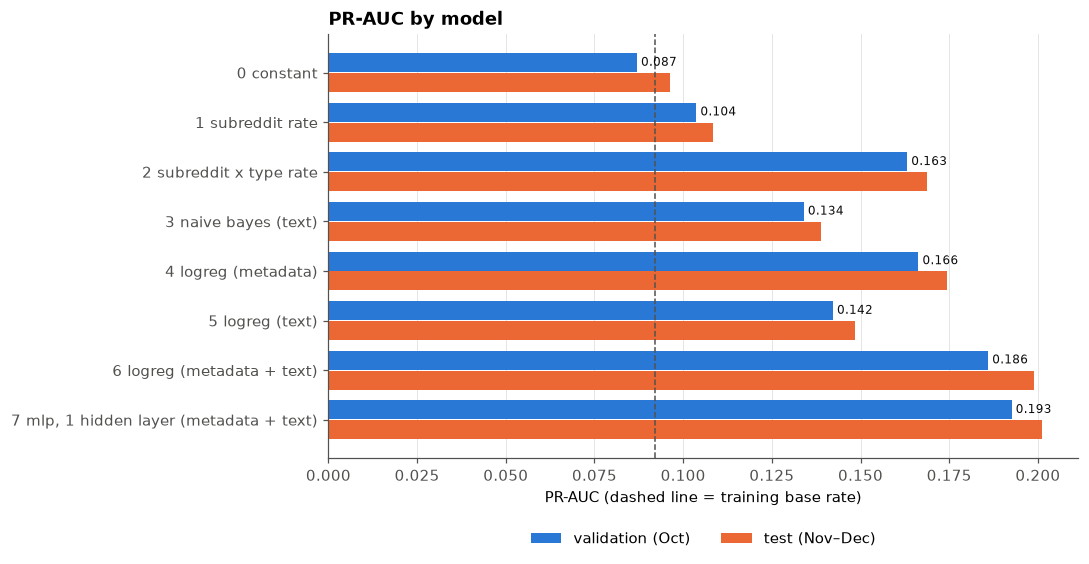

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.8))
names = res.index[::-1]
y = np.arange(len(names))
ax.barh(y + 0.2, res.loc[names, "val_pr_auc"], height=0.38, color=BLUE, label="validation (Oct)")
ax.barh(y - 0.2, res.loc[names, "test_pr_auc"], height=0.38, color=ORANGE, label="test (Nov–Dec)")
for yi, v in zip(y, res.loc[names, "val_pr_auc"]):
    ax.text(v, yi + 0.2, f" {v:.3f}", va="center", fontsize=8, color=INK)
ax.set_yticks(y, names)
ax.axvline(base_rate, color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("PR-AUC (dashed line = training base rate)")
ax.set_title("PR-AUC by model"); ax.grid(axis="y", visible=False)
plt.tight_layout()
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)

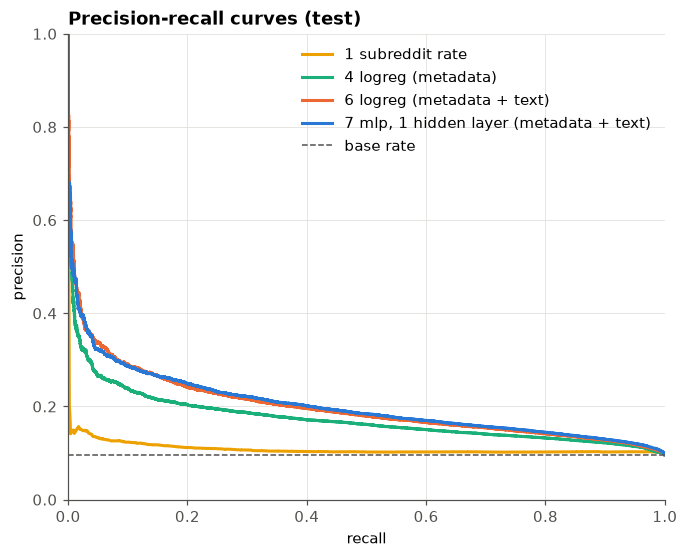

In [21]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, color in [("1 subreddit rate", YELLOW), ("4 logreg (metadata)", AQUA),
                    ("6 logreg (metadata + text)", ORANGE), ("7 mlp, 1 hidden layer (metadata + text)", BLUE)]:
    prec, rec, _ = precision_recall_curve(y_test, preds[name][1])
    ax.plot(rec, prec, color=color, linewidth=2, label=name)
ax.axhline(y_test.mean(), color=MUTED, linewidth=1, linestyle="--", label="base rate")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Precision-recall curves (test)")
ax.legend(frameon=False)

## Next steps

- Tune the strongest models on the validation set (regularization `C`, TF-IDF size, hidden units).
- Decide on the open design questions: the success threshold, the minimum subreddit size, a threshold per
  time period (not only per subreddit), and whether to add author history (it needs a time-aware computation
  to avoid leaks).
- Report final numbers on the test set only once, after the model choice is fixed.